# W05B 실습 A · 내적에서 SGD 한 단계까지

**딥러닝응용I(추천시스템) · 동덕여자대학교 · 유원상 교수 · 2026-2**

2026년 10월 1일 · W05B · 주교재 4.1–4.3.
목표: 관측 마스크, 내적, 편향, 기울기와 동시 갱신을 숫자로 설명합니다.
CPU 런타임으로 실행합니다. 파일 → Drive에 사본 저장 후 첫 셀부터 실행하세요.
설치 후 재시작 안내가 나오면 런타임을 재시작하고 첫 셀부터 실행합니다.
None과 빈 문자열은 연습용입니다. 미완성 문제를 건너뛰어도 독립 시연은 실행됩니다.
자동 검사가 통과해도 자신의 빈칸 답이 모두 맞았다는 뜻은 아닙니다.


In [ ]:
import os,sys,subprocess
os.environ['GRADIO_ANALYTICS_ENABLED']='False'
IN_COLAB='google.colab' in sys.modules
COURSE_VERSION='2026-fall-w05b'
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q',
        f'luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}',
        'gradio==6.26.0'],check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
from luna_recsys.mf_sgd import MFSGD,sgd_step
from luna_recsys.mf_lab import step_view,training_view,build_mf_app
from luna_recsys.model_comparison import comparison_toy,definition_link
print('Python',sys.version.split()[0],'수업 버전',COURSE_VERSION)


## 함수 설명과 정의 바로가기
설치한 버전의 정의 첫 줄로 연결됩니다. `MFSGD(...)`는 설정만 저장하고
`fit(관측표)`이 초기화부터 다시 학습합니다. `history_`는 epoch·train_rmse·objective 표입니다.
`predict(ID,ID)`는 실수, `explain(ID,ID)`은 평균·편향·내적·알려진 ID 여부 사전,
`recommend(ID,N)`은 이미 본 영화를 제외한 표를 반환합니다.
`sgd_step(p,q,rating,...)`는 원본을 바꾸지 않고 갱신 전후 사전을 반환합니다.
`build_mf_app(관측표)`는 화면만 만들며 `launch`는 별도입니다.


In [ ]:
apis=[MFSGD,MFSGD.fit,MFSGD.predict,MFSGD.explain,MFSGD.rmse,MFSGD.recommend,
      sgd_step,step_view,training_view,build_mf_app,comparison_toy,definition_link]
display(Markdown('\n'.join(f'- [{obj.__qualname__}]({definition_link(obj,COURSE_VERSION)})' for obj in apis)))
toy=comparison_toy()
ratings=toy.ratings.copy()
print('작은 예제 관측 수:',len(ratings))
display(ratings.pivot(index='user_id',columns='movie_id',values='rating'))


## 1. 관측 수와 차원을 먼저 확인하기
NaN은 실제 0점이 아닙니다. 학습 입력은 관측 행 18개입니다.
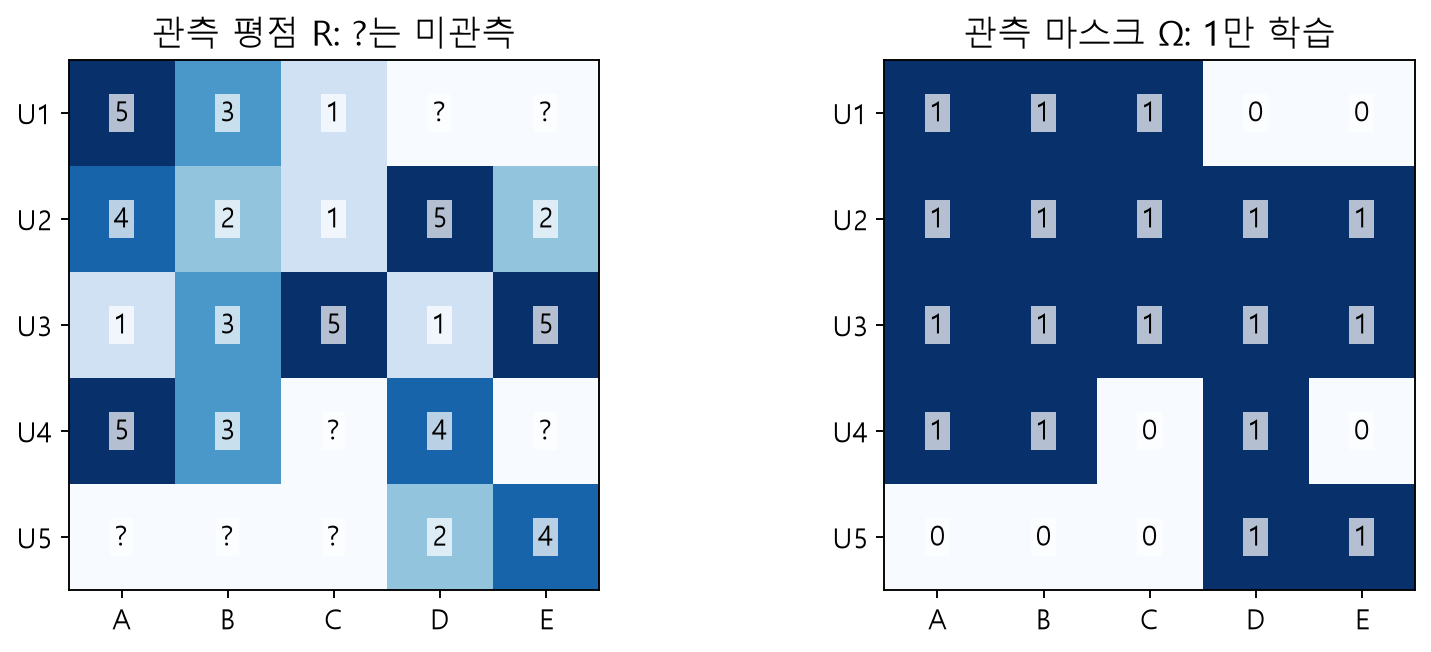


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w05b/course/notion/assets/w05b/observed-mask.png)


### A1 · 빈칸: 평균의 분모와 벡터 길이
관측 합은 56입니다. 평균의 분모, P의 모양, Q 전치의 모양을 적으세요.
힌트: 전체 칸 수와 관측 수를 구분합니다. 자가 점검: 두 행렬의 안쪽 차원이 같습니다.


In [ ]:
observed_denominator=None
p_shape=None
qt_shape=None
print('A1 답:',observed_denominator,p_shape,qt_shape)


## 2. 예측을 네 부분으로 분해하기
평균3, 사용자 편향0.1, 영화 편향-0.2를 이미 학습했다고 가정한 한 시점입니다.
이 숫자는 18관측 평균56/18과 별개의 손계산 예제입니다.
예측=평균+사용자 편향+영화 편향+내적. 잔차=실제-예측.


In [ ]:
p=np.array([.2,.4]);q=np.array([.5,-.1])
mu,bu,bi,r=3.,.1,-.2,4.
prediction=mu+bu+bi+p@q
error=r-prediction
display(pd.DataFrame({'part':['mean','user bias','item bias','factor 1','factor 2'],
                     'contribution':[mu,bu,bi,*(p*q)]}))
print('예측:',prediction,'잔차:',error,'1/2 제곱손실:',.5*error**2)


### A2 · 예상하기
p의 둘째 좌표는 늘어날까요, 줄어들까요? q2의 부호로 설명하세요.
힌트: 오차가 양수라고 모든 모수를 늘리는 것은 아닙니다.


In [ ]:
a2_reason=''


## 3. 기울기에서 갱신으로
한 관측 손실: `0.5*e**2+0.5*beta*(p@p+q@q+bu**2+bi**2)`.
p의 기울기는 `-e*q+beta*p`. 반대 방향으로 alpha만큼 움직입니다.
두 새 벡터를 모두 이전 상태에서 계산합니다.


In [ ]:
alpha,beta=.05,.02
p_old,q_old=p.copy(),q.copy()
p_new=p_old+alpha*(error*q_old-beta*p_old)
q_new=q_old+alpha*(error*p_old-beta*q_old)
trace=sgd_step(p,q,r,mean=mu,user_bias=bu,item_bias=bi,
               learning_rate=alpha,regularization=beta)
display(pd.DataFrame({'parameter':['p1','p2','q1','q2','bu','bi'],
 'before':[*p,*q,bu,bi],
 'after':[*trace['p_new'],*trace['q_new'],trace['user_bias_new'],trace['item_bias_new']]}))
print('갱신 후 예측:',trace['prediction_new'])
print('갱신 전/후 목적함수:',trace['loss'],trace['loss_new'])


In [ ]:
np.testing.assert_allclose(p_new,[.2258,.3944],atol=1e-12)
np.testing.assert_allclose(q_new,[.5099,-.0791],atol=1e-12)
assert np.isclose(trace['prediction_new'],3.08803838)
np.testing.assert_array_equal(p,[.2,.4])
assert trace['loss_new']<trace['loss']


### A3 · 디버깅
`p = p+alpha*(error*q-beta*p)` 다음에 `q = q+alpha*(error*p-beta*q)`를 실행했습니다.
왜 같은 갱신이 아닌가요? 힌트: 둘째 줄의 p는 어느 시점인가요? 수정안을 적으세요.


In [ ]:
a3_fix=''


## 4. 코드를 그림과 연결하기
`step_view`는 문자열·표·그림을 반환합니다. 같은 초기 상태에서 학습률만 바꿉니다.
반복 학습이 아니라 한 단계 비교입니다.


In [ ]:
for learning_rate in [.01,.05,.2]:
    message,table,figure=step_view(4,learning_rate,.02)
    print('alpha=',learning_rate,message)
    display(table,figure)


### A4 · 비교 기록
p2의 변화 방향, 예측 변화 폭, 목적함수 변화를 기록하세요.
학습률을 계속 높여도 항상 좋아질까요? 관측과 추측을 구분하세요.


In [ ]:
a4_observation=''
a4_limit=''


## 점검 퀴즈
1. 미관측 평점을 0으로 채우면 어떤 가정이 추가되는가?
2. 사용자 5명, 영화 5편, K=2일 때 P와 Q의 모양은?
3. 잔차가 양수여도 p의 어떤 좌표는 왜 감소하는가?
4. 갱신된 P를 Q 갱신에 사용하면 같은 시점 기울기와 무엇이 달라지는가?
5. 학습 RMSE와 정규화 목적함수는 왜 값이 다른가?
6. train RMSE 감소만으로 실제 추천 품질 향상을 결론 내릴 수 있는가?

## 핵심 정리와 출처
관측만 학습하고, 같은 시점의 기울기로 모수를 갱신하고, 결과의 평가 범위를 명시합니다.
임일, 주교재 4.1–4.3. 예제·NumPy 구현·앱은 수업용 독립 제작입니다.
[Google MF](https://developers.google.com/machine-learning/recommendation/collaborative/matrix)
· [Surprise MF](https://surprise.readthedocs.io/en/stable/matrix_factorization.html)
· [GroupLens README](https://files.grouplens.org/datasets/movielens/ml-100k-README.txt)
· [Gradio Blocks](https://www.gradio.app/docs/gradio/blocks)
